# H2 – Einfluss zeitlicher Merkmale

|                   |                                                                                         |
|-------------------|-----------------------------------------------------------------------------------------|
| **Hypothese**     | Die Berücksichtigung zeitlicher Merkmale (Uhrzeit, Jahreszeit) verbessert die Prognose. |
| **Typ**           | Unterschiedshypothese / gerichtet                                                       |
| **H₀**            | MAE(mit Zeitfeatures) ≥ MAE(ohne)                                                       |
| **H₁**            | MAE(mit Zeitfeatures) < MAE(ohne)                                                       |
| **Testverfahren** | Paired t-Test                                                                           |

## 0 · Setup

In [8]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.evaluation.results import load_predictions

ALPHA = 0.05
P_NOM = 13_500.0

RESULTS_LR = Path('../../results/01_linear_regression')
RESULTS_RF = Path('../../results/02_random_forest')

MODEL_ORDER = ['LR BASE', 'LR TIME', 'RF BASE', 'RF TIME']
MODEL_COLORS = {
    'LR BASE': '#4C72B0',
    'LR TIME': '#64B5CD',
    'RF BASE': '#DD8452',
    'RF TIME': '#E6A86C',
}

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

## 1 · Vorhersagen laden

In [9]:
# ============================================================
# Vorhersagen laden (BASE vs TIME)
# ============================================================
lr_base = load_predictions(RESULTS_LR, 'linear_regression_base', split='val')
lr_time = load_predictions(RESULTS_LR, 'linear_regression_base_with_time', split='val')

rf_base = load_predictions(RESULTS_RF, 'random_forest_base', split='val')
rf_time = load_predictions(RESULTS_RF, 'random_forest_base_with_time', split='val')


# ============================================================
# Gemeinsamen Index bestimmen
# (WICHTIG für fairen Vergleich!)
# ============================================================
idx = (
    lr_base.index
    .intersection(lr_time.index)
    .intersection(rf_base.index)
    .intersection(rf_time.index)
)

lr_base = lr_base.loc[idx]
lr_time = lr_time.loc[idx]
rf_base = rf_base.loc[idx]
rf_time = rf_time.loc[idx]


# ============================================================
# Info
# ============================================================
print(f"Val-Set: {idx.min().date()} → {idx.max().date()}  ({len(idx):,} Zeitschritte)")

Val-Set: 2024-06-14 → 2024-12-15  (17,643 Zeitschritte)


## 3 · Aggregierte Kennzahlen (Überblick)

Vergleich der aggregierten MAE- und RMSE-Werte auf dem Val-Set.

In [10]:
def mae_of(df):
    return (df['y_true'] - df['y_pred']).abs().mean()

def rmse_of(df):
    return ((df['y_pred'] - df['y_true']) ** 2).mean() ** 0.5

def compute_metrics(df):
    ae = (df['y_pred'] - df['y_true']).abs()
    se = (df['y_pred'] - df['y_true']) ** 2
    return {
        'MAE [W]': ae.mean(),
        'RMSE [W]': np.sqrt(se.mean()),
        'nMAE': ae.mean() / P_NOM,
        'R²': 1 - se.sum() / ((df['y_true'] - df['y_true'].mean()) ** 2).sum()
    }

MODEL_DATA_VAL = {
    'LR BASE': lr_base,
    'LR TIME': lr_time,
    'RF BASE': rf_base,
    'RF TIME': rf_time,
}

summary_df = pd.DataFrame({m: compute_metrics(df) for m, df in MODEL_DATA_VAL.items()}).T
display(summary_df.round(4))

,MAE [W],RMSE [W],nMAE,R²
LR BASE,242.8122,478.9507,0.0180,0.4576
LR TIME,240.5605,444.3188,0.0178,0.5332
RF BASE,239.3219,489.0383,0.0177,0.4345
RF TIME,145.6719,395.8706,0.0108,0.6294


## 4 · Paired t-Test

**Testprozedur:**  
Für jeden Zeitschritt `t` wird die Differenz der absoluten Fehler berechnet:
$$d_t = |e_{\text{BASE},t}| - |e_{\text{TIME},t}|$$

- `d_t > 0` → Modell mit Zeitmerkmalen ist besser  
- `d_t < 0` → Basis-Modell ist besser  

**Einseitiger t-Test:** H₂: Der mittlere absolute Fehler des Zeitmodells ist kleiner.

In [11]:
def paired_ttest(base_df, time_df, model_name):
    """Paired t-Test: H2: mean(|e_base| - |e_time|) > 0"""
    ae_base = (base_df['y_true'] - base_df['y_pred']).abs()
    ae_time = (time_df['y_true'] - time_df['y_pred']).abs()
    d = ae_base - ae_time  # positiv = TIME besser

    t_stat, p_two = stats.ttest_1samp(d.dropna(), popmean=0)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

    return {
        'Modell': model_name,
        'n': int(d.notna().sum()),
        'MAE BASE [W]': ae_base.mean(),
        'MAE TIME [W]': ae_time.mean(),
        'RMSE BASE [W]': np.sqrt(((base_df['y_pred'] - base_df['y_true']) ** 2).mean()),
        'RMSE TIME [W]': np.sqrt(((time_df['y_pred'] - time_df['y_true']) ** 2).mean()),
        'mean(d) [W]': d.mean(),
        't-Statistik': t_stat,
        'p-Wert (1-s.)': p_one,
        f'H₂ (α={ALPHA})': p_one < ALPHA
    }

ttest_rows = [
    paired_ttest(lr_base, lr_time, 'Linear Regression'),
    paired_ttest(rf_base, rf_time, 'Random Forest'),
]

ttest_df = pd.DataFrame(ttest_rows).set_index('Modell')
display(ttest_df.round(4))

,n,MAE BASE [W],MAE TIME [W],RMSE BASE [W],RMSE TIME [W],mean(d) [W],t-Statistik,p-Wert (1-s.),H₂ (α=0.05)
Modell,,,,,,,,,
Linear Regression,17643,242.8122,240.5605,478.9507,444.3188,2.2518,2.0337,0.021,True
Random Forest,17643,239.3219,145.6719,489.0383,395.8706,93.6501,51.3550,0.000,True


## 5 · Interpretation des t-Tests

In [12]:
print(f"{'='*68}")
print(f"  H2-TEST: Paired t-Test (α = {ALPHA}, einseitig, Val-Set)")
print(f"{'='*68}")

for model_name in ['Linear Regression', 'Random Forest']:
    row = ttest_df.loc[model_name]
    confirmed = row[f'H₂ (α={ALPHA})']
    mean_d = row['mean(d) [W]']
    p = row['p-Wert (1-s.)']
    mae_base = row['MAE BASE [W]']
    mae_time = row['MAE TIME [W]']
    rmse_base = row['RMSE BASE [W]']
    rmse_time = row['RMSE TIME [W]']

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"MAE:  BASE = {mae_base:.2f} W | TIME = {mae_time:.2f} W")
    print(f"RMSE: BASE = {rmse_base:.2f} W | TIME = {rmse_time:.2f} W")
    print(f"Mittlere Fehlerdifferenz d = |e_BASE| - |e_TIME|: {mean_d:.2f} W")
    print(f"p-Wert (einseitig): {p:.6f}")

    if confirmed:
        print("→ H₂ wird bestätigt: Zeitmerkmale verbessern die Prognose signifikant.")
    else:
        print("→ H₂ kann nicht bestätigt werden: Keine signifikante Verbesserung durch Zeitmerkmale.")

  H2-TEST: Paired t-Test (α = 0.05, einseitig, Val-Set)

Linear Regression
-----------------
MAE:  BASE = 242.81 W | TIME = 240.56 W
RMSE: BASE = 478.95 W | TIME = 444.32 W
Mittlere Fehlerdifferenz d = |e_BASE| - |e_TIME|: 2.25 W
p-Wert (einseitig): 0.020999
→ H₂ wird bestätigt: Zeitmerkmale verbessern die Prognose signifikant.

Random Forest
-------------
MAE:  BASE = 239.32 W | TIME = 145.67 W
RMSE: BASE = 489.04 W | TIME = 395.87 W
Mittlere Fehlerdifferenz d = |e_BASE| - |e_TIME|: 93.65 W
p-Wert (einseitig): 0.000000
→ H₂ wird bestätigt: Zeitmerkmale verbessern die Prognose signifikant.


## 6 · Visualisierung

### 6.1 – MAE- und RMSE-Vergleich (Val-Set)

/var/folders/0q/trpx35nn6hq8qv850qgq5csm0000gn/T/ipykernel_49388/1438708790.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_ORDER, rotation=15)
/var/folders/0q/trpx35nn6hq8qv850qgq5csm0000gn/T/ipykernel_49388/1438708790.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_ORDER, rotation=15)


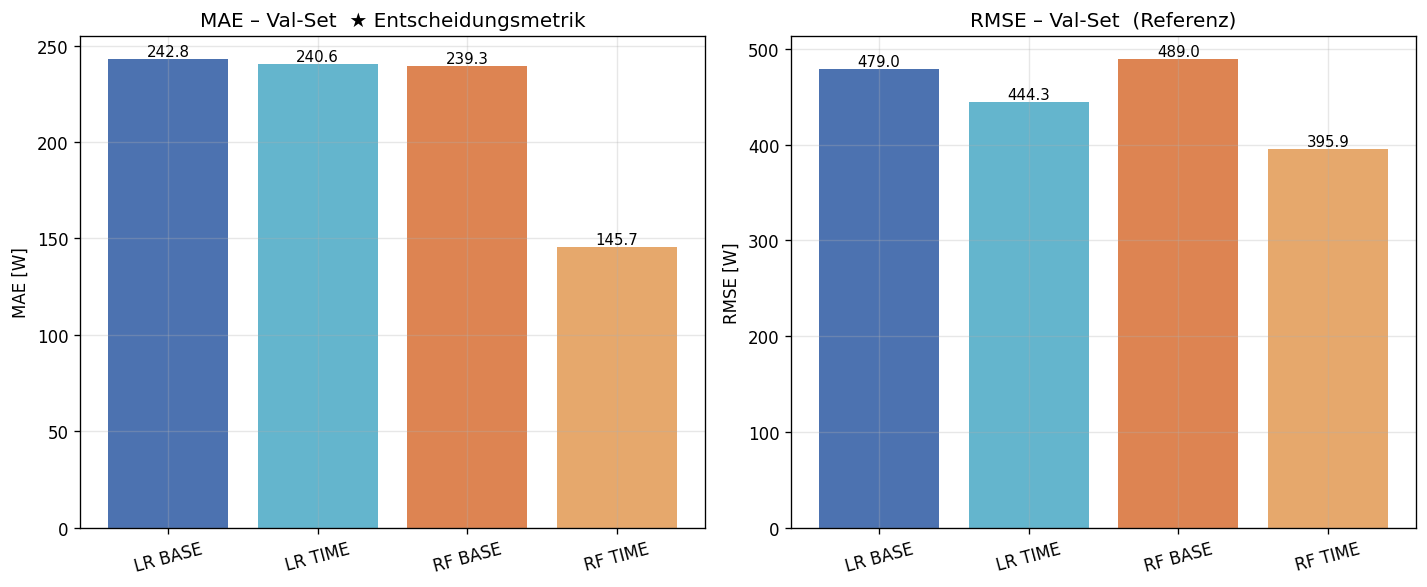

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric_fn, title, ylabel in [
    (axes[0], mae_of,  'MAE – Val-Set  ★ Entscheidungsmetrik', 'MAE [W]'),
    (axes[1], rmse_of, 'RMSE – Val-Set  (Referenz)', 'RMSE [W]'),
]:
    values = [metric_fn(MODEL_DATA_VAL[m]) for m in MODEL_ORDER]
    colors = [MODEL_COLORS[m] for m in MODEL_ORDER]

    bars = ax.bar(MODEL_ORDER, values, color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(MODEL_ORDER, rotation=15)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 6.2 – Verteilung der Fehlerdifferenzen `d_t = |e_BASE| − |e_TIME|`

Positive Werte bedeuten: Modell mit Zeitmerkmalen ist besser.

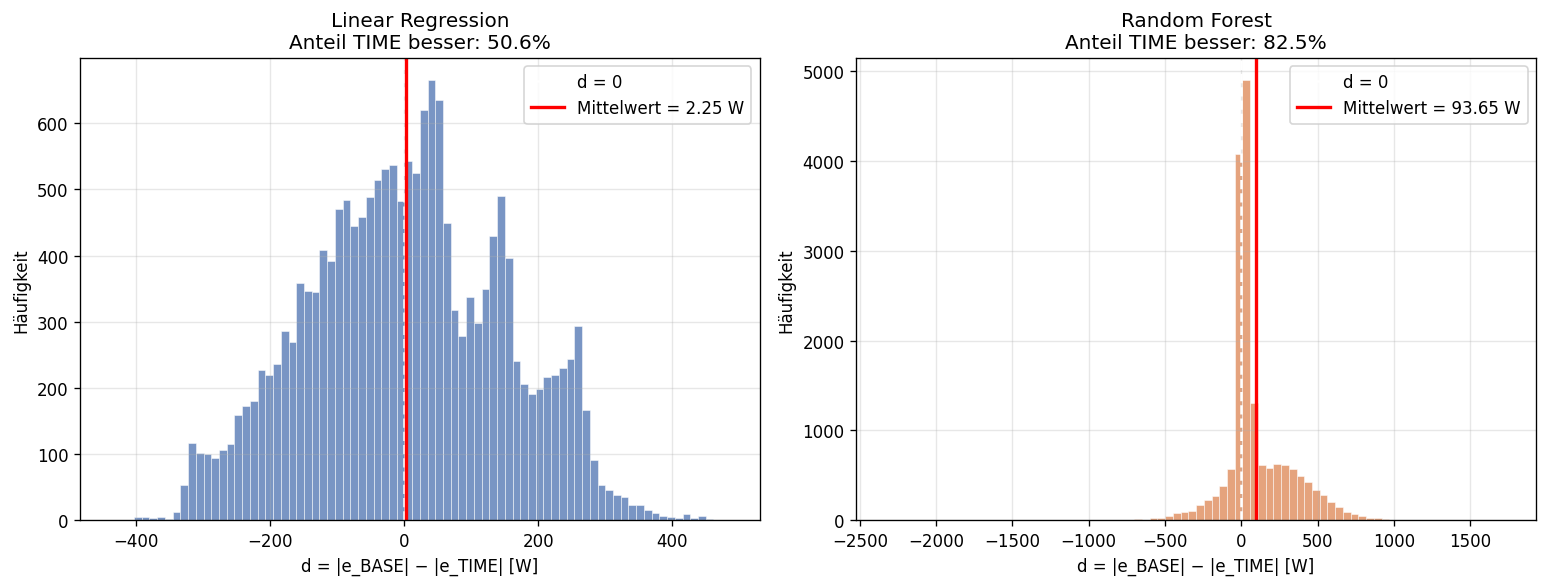

In [14]:
diffs = {
    'Linear Regression': (lr_base['y_true'] - lr_base['y_pred']).abs()
                       - (lr_time['y_true'] - lr_time['y_pred']).abs(),
    'Random Forest':     (rf_base['y_true'] - rf_base['y_pred']).abs()
                       - (rf_time['y_true'] - rf_time['y_pred']).abs(),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (model_name, color) in zip(axes, [
    ('Linear Regression', '#4C72B0'),
    ('Random Forest', '#DD8452'),
]):
    d = diffs[model_name].dropna()
    mean_d = d.mean()
    pct_better = (d > 0).mean() * 100

    ax.hist(d, bins=80, color=color, edgecolor='white', linewidth=0.4, alpha=0.75)
    ax.axvline(0, color='white', lw=1.5, ls='--', label='d = 0')
    ax.axvline(mean_d, color='red', lw=2.0, ls='-', label=f'Mittelwert = {mean_d:.2f} W')

    ax.set_title(f'{model_name}\nAnteil TIME besser: {pct_better:.1f}%')
    ax.set_xlabel('d = |e_BASE| − |e_TIME| [W]')
    ax.set_ylabel('Häufigkeit')
    ax.legend()

plt.tight_layout()
plt.show()

## 7 · Saisonale Aufschlüsselung (Val-Set)

Aufschlüsselung nach Jahreszeit zeigt, ob Zeitmerkmale besonders in bestimmten Perioden hilfreich sind.

In [15]:
SEASON_MAP = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Frühling', 4: 'Frühling', 5: 'Frühling',
    6: 'Sommer', 7: 'Sommer', 8: 'Sommer',
    9: 'Herbst', 10: 'Herbst', 11: 'Herbst'
}
SEASON_ORDER = ['Winter', 'Frühling', 'Sommer', 'Herbst']

season_rows = []
comparisons = {
    'LR': ('LR BASE', lr_base, 'LR TIME', lr_time),
    'RF': ('RF BASE', rf_base, 'RF TIME', rf_time),
}

for short_name, (base_name, base_df, time_name, time_df) in comparisons.items():
    season = base_df.index.month.map(SEASON_MAP)

    for s in SEASON_ORDER:
        base_sub = base_df[season == s]
        time_sub = time_df[season == s]

        if base_sub.empty or time_sub.empty:
            continue

        season_rows.append({
            'Modell': short_name,
            'Saison': s,
            'MAE BASE [W]': mae_of(base_sub),
            'MAE TIME [W]': mae_of(time_sub),
            'ΔMAE [W]': mae_of(base_sub) - mae_of(time_sub),
            'RMSE BASE [W]': rmse_of(base_sub),
            'RMSE TIME [W]': rmse_of(time_sub),
            'ΔRMSE [W]': rmse_of(base_sub) - rmse_of(time_sub),
        })

season_df = pd.DataFrame(season_rows)
display(season_df.round(3))

,Modell,Saison,MAE BASE [W],MAE TIME [W],ΔMAE [W],RMSE BASE [W],RMSE TIME [W],ΔRMSE [W]
0,LR,Winter,54.508,197.051,-142.543,115.022,225.665,-110.643
1,LR,Sommer,353.082,283.350,69.732,606.567,545.137,61.430
2,LR,Herbst,176.899,210.378,-33.479,378.696,366.163,12.534
3,RF,Winter,38.284,26.201,12.083,105.873,81.734,24.139
4,RF,Sommer,358.737,207.558,151.179,630.046,492.640,137.406
5,RF,Herbst,167.493,110.828,56.665,371.977,325.299,46.678


## 8 · Fazit

In [16]:
print("=" * 70)
print("FAZIT – H2: Verbessern Zeitmerkmale die Prognose?")
print("=" * 70)

for model_name in ['Linear Regression', 'Random Forest']:
    row = ttest_df.loc[model_name]
    confirmed = row[f'H₂ (α={ALPHA})']
    mae_base = row['MAE BASE [W]']
    mae_time = row['MAE TIME [W]']
    rmse_base = row['RMSE BASE [W]']
    rmse_time = row['RMSE TIME [W]']
    mean_d = row['mean(d) [W]']
    p = row['p-Wert (1-s.)']

    delta_mae_pct = (mae_time - mae_base) / mae_base * 100

    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"MAE:  {mae_base:.2f} W → {mae_time:.2f} W  ({delta_mae_pct:+.2f}%)")
    print(f"RMSE: {rmse_base:.2f} W → {rmse_time:.2f} W")
    print(f"mean(d): {mean_d:.2f} W")
    print(f"p-Wert: {p:.6f}")

    if confirmed:
        print("Ergebnis: H₂ bestätigt.")
    else:
        print("Ergebnis: H₂ nicht bestätigt.")

FAZIT – H2: Verbessern Zeitmerkmale die Prognose?

Linear Regression
-----------------
MAE:  242.81 W → 240.56 W  (-0.93%)
RMSE: 478.95 W → 444.32 W
mean(d): 2.25 W
p-Wert: 0.020999
Ergebnis: H₂ bestätigt.

Random Forest
-------------
MAE:  239.32 W → 145.67 W  (-39.13%)
RMSE: 489.04 W → 395.87 W
mean(d): 93.65 W
p-Wert: 0.000000
Ergebnis: H₂ bestätigt.
